# Label Propagation

---

## Intuition

**Label Propagation** is a *semi-supervised* learning method: given a small set of labeled points and a large set of unlabeled points, it spreads labels from labeled to unlabeled points by following the **graph structure** of the data.

The key assumption is the **manifold assumption**: nearby points in feature space likely belong to the same class. Labels flow along edges of a graph built from point similarities, like ink spreading through connected capillaries.

This is especially powerful when labels are scarce (e.g. 4 labeled out of 100 total).

---

## Algorithm

**Step 1. Build the RBF affinity matrix** $W$:
$$W_{ij} = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$
Large $\gamma$: only very close points get high affinity. Small $\gamma$: affinity is spread more broadly.

**Step 2. Row-normalize** to get the transition matrix (each row sums to 1):
$$T = D^{-1} W \quad \text{where } D_{ii} = \sum_j W_{ij}$$
$T_{ij}$ is the probability of "jumping" from node $i$ to node $j$.

**Step 3. Iterative update with clamping:**
$$F \leftarrow T \cdot F$$
After each step, reset labeled rows back to their original one-hot encoding (clamping). This ensures labeled points never drift.

**Step 4. Convergence:** the fixed point satisfies:
$$F^* = (I - T_{uu})^{-1} T_{ul} F_l$$
where subscript $u$ = unlabeled, $l$ = labeled.

**Step 5. Assign** each unlabeled point to $\arg\max_c F^*_{ic}$.

---

## Advantages and Disadvantages

| | |
|---|---|
| **Advantages** | Works with very few labels; exploits data geometry; interpretable (labels flow along edges); closed-form solution exists |
| **Disadvantages** | Assumes manifold structure (fails if labeled and unlabeled come from different distributions); sensitive to $\gamma$; $O(n^2)$ for dense graphs |

---

## When to Use Label Propagation

- You have very **few labeled samples** (even 1-2 per class can suffice)
- The data has clear **cluster structure** (labeled and unlabeled points from the same class form connected components)
- You are in a **semi-supervised setting** where labeling is expensive
- Example applications: image segmentation, text classification with sparse labels, medical diagnosis

---

## Summary Table

| Property | Value |
|---|---|
| Type | Semi-supervised (few labels + many unlabeled) |
| Graph construction | RBF kernel affinity matrix |
| Key parameter | $\gamma$ (RBF bandwidth) |
| Label update | Iterative with clamping of labeled rows |
| Convergence | Guaranteed (spectral radius of $T_{uu} < 1$) |
| Closed-form solution | Yes: $F^* = (I - T_{uu})^{-1} T_{ul} F_l$ |
| Handles multiclass | Yes (one-hot label matrix) |
| Scales to large data | No ($O(n^2)$ affinity matrix) |

---

**Dataset:** Synthetic two-cluster data with only 4 labeled points  
**Task:** Propagate labels to all 96 unlabeled points.

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme()

from rice_ml.unsupervised_learning import LabelPropagation
from rice_ml.preprocess import StandardScaler

## Dataset Description

**Synthetic dataset:**
- **100 points** in 2D, organized in **2 well-separated Gaussian clusters** (50 points each)
- Cluster 0: centered at $(-3, -3)$ with $\sigma = 0.5$
- Cluster 1: centered at $(3, 3)$ with $\sigma = 0.5$

**Labels:**
- Only **4 points are labeled** (2 per cluster): indices 0, 1 (class 0) and 98, 99 (class 1)
- The remaining **96 points** have label $= -1$ (unlabeled)

**Task:** Use the 4 labeled seed points to propagate labels to all 96 unlabeled points via the RBF affinity graph. The label propagation should achieve near-perfect accuracy because the clusters are well-separated.

In [20]:
# Generate two clusters with only 2 labeled points each
rng = np.random.default_rng(42)
X0 = rng.normal([-3, -3], 0.5, (50, 2))
X1 = rng.normal([3, 3], 0.5, (50, 2))
X = np.vstack([X0, X1])

# All unlabeled (-1) except 2 points per class
y = np.full(100, -1)
y[0], y[1]   = 0, 0
y[99], y[98] = 1, 1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_labeled = (y != -1).sum()
print(f'Total samples: {len(X)}')
print(f'Labeled:       {n_labeled} ({100*n_labeled/len(X):.0f}%)')
print(f'Unlabeled:     {(y == -1).sum()} ({100*(y==-1).sum()/len(X):.0f}%)')

Total samples: 100
Labeled:       4 (4%)
Unlabeled:     96 (96%)


## EDA: Labeled vs Unlabeled Points

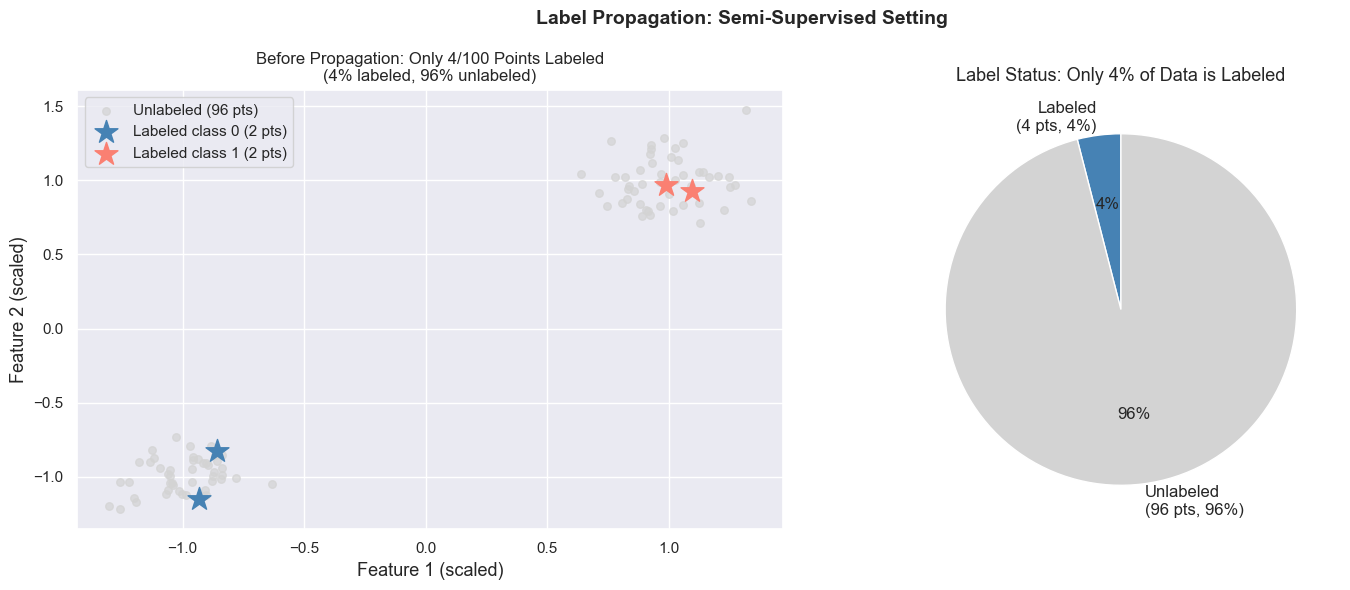

In [21]:
# --- EDA: Show labeled vs unlabeled before propagation ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: all points colored by label status
axes[0].scatter(X_scaled[y == -1, 0], X_scaled[y == -1, 1],
                c='lightgray', s=30, alpha=0.7, label=f'Unlabeled ({(y==-1).sum()} pts)')
axes[0].scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1],
                c='steelblue', s=300, marker='*', zorder=5, label='Labeled class 0 (2 pts)')
axes[0].scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1],
                c='salmon', s=300, marker='*', zorder=5, label='Labeled class 1 (2 pts)')
axes[0].set_xlabel('Feature 1 (scaled)', fontsize=13)
axes[0].set_ylabel('Feature 2 (scaled)', fontsize=13)
axes[0].set_title(f'Before Propagation: Only {n_labeled}/{len(X)} Points Labeled\n'
                  f'({100*n_labeled/len(X):.0f}% labeled, {100*(y==-1).sum()/len(X):.0f}% unlabeled)',
                  fontsize=12)
axes[0].legend(fontsize=11)

# Right: pie chart of label status
n_unlab = (y == -1).sum()
axes[1].pie([n_labeled, n_unlab],
            labels=[f'Labeled\n({n_labeled} pts, {100*n_labeled/len(X):.0f}%)',
                    f'Unlabeled\n({n_unlab} pts, {100*n_unlab/len(X):.0f}%)'],
            colors=['steelblue', 'lightgray'],
            startangle=90, autopct='%1.0f%%', textprops={'fontsize': 12})
axes[1].set_title('Label Status: Only 4% of Data is Labeled', fontsize=13)

plt.suptitle('Label Propagation: Semi-Supervised Setting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## RBF Affinity Concept: Illustrated

The diagram below shows how the RBF affinity matrix creates a weighted graph. nearby points get high affinity (thick edges), distant points get low affinity (thin edges). Labels flow along thick edges.

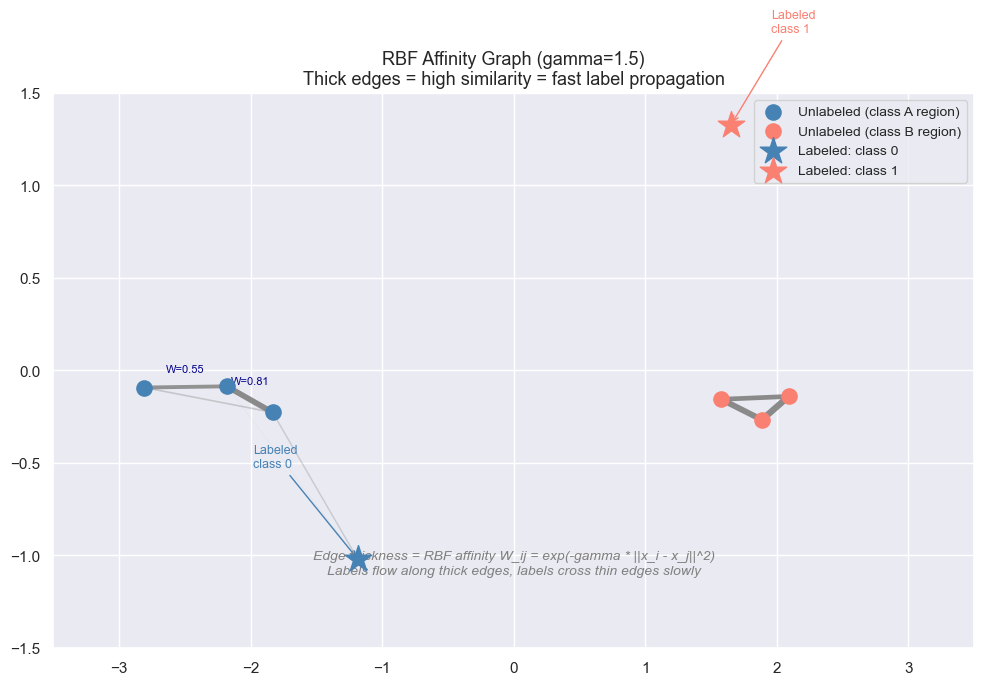

In [22]:
# --- Diagram: RBF affinity graph ---
rng_d = np.random.default_rng(3)
# 8 points: 4 in each group
pts_A = rng_d.normal([-2, 0], 0.4, (4, 2))
pts_B = rng_d.normal([2, 0], 0.4, (4, 2))
pts_all = np.vstack([pts_A, pts_B])

gamma_diag = 1.5
n_pts = len(pts_all)
W_diag = np.exp(-gamma_diag * np.sum((pts_all[:, None, :] - pts_all[None, :, :]) ** 2, axis=2))
np.fill_diagonal(W_diag, 0)

fig, ax = plt.subplots(figsize=(10, 7))

# Draw edges with thickness proportional to W
for i in range(n_pts):
    for j in range(i+1, n_pts):
        w = W_diag[i, j]
        if w > 0.05:  # only draw significant edges
            lw = w * 5
            alpha = min(w * 1.5, 0.9)
            ax.plot([pts_all[i, 0], pts_all[j, 0]],
                    [pts_all[i, 1], pts_all[j, 1]],
                    'gray', linewidth=lw, alpha=alpha, zorder=1)
            if w > 0.4 and i < 4 and j < 4:  # label a few within-group weights
                mx, my = (pts_all[i] + pts_all[j]) / 2
                ax.text(mx, my + 0.08, f'W={w:.2f}', fontsize=8, color='darkblue',
                        ha='center', zorder=3)

# Plot points: star for labeled, circle for unlabeled
ax.scatter(pts_A[1:, 0], pts_A[1:, 1], c='steelblue', s=120, zorder=4, label='Unlabeled (class A region)')
ax.scatter(pts_B[1:, 0], pts_B[1:, 1], c='salmon', s=120, zorder=4, label='Unlabeled (class B region)')
# Labeled seeds
ax.scatter([pts_A[0, 0]], [pts_A[0, 1]], c='steelblue', s=400, marker='*',
           zorder=5, label='Labeled: class 0')
ax.scatter([pts_B[0, 0]], [pts_B[0, 1]], c='salmon', s=400, marker='*',
           zorder=5, label='Labeled: class 1')
ax.annotate('Labeled\nclass 0', xy=pts_A[0], xytext=(pts_A[0, 0]-0.8, pts_A[0, 1]+0.5),
            fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))
ax.annotate('Labeled\nclass 1', xy=pts_B[0], xytext=(pts_B[0, 0]+0.3, pts_B[0, 1]+0.5),
            fontsize=9, color='salmon',
            arrowprops=dict(arrowstyle='->', color='salmon'))

ax.text(0, -1.1,
        'Edge thickness = RBF affinity W_ij = exp(-gamma * ||x_i - x_j||^2)\n'
        'Labels flow along thick edges, labels cross thin edges slowly',
        ha='center', fontsize=10, style='italic', color='gray')

ax.set_title(f'RBF Affinity Graph (gamma={gamma_diag})\n'
             'Thick edges = high similarity = fast label propagation', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-1.5, 1.5)
plt.tight_layout()
plt.show()

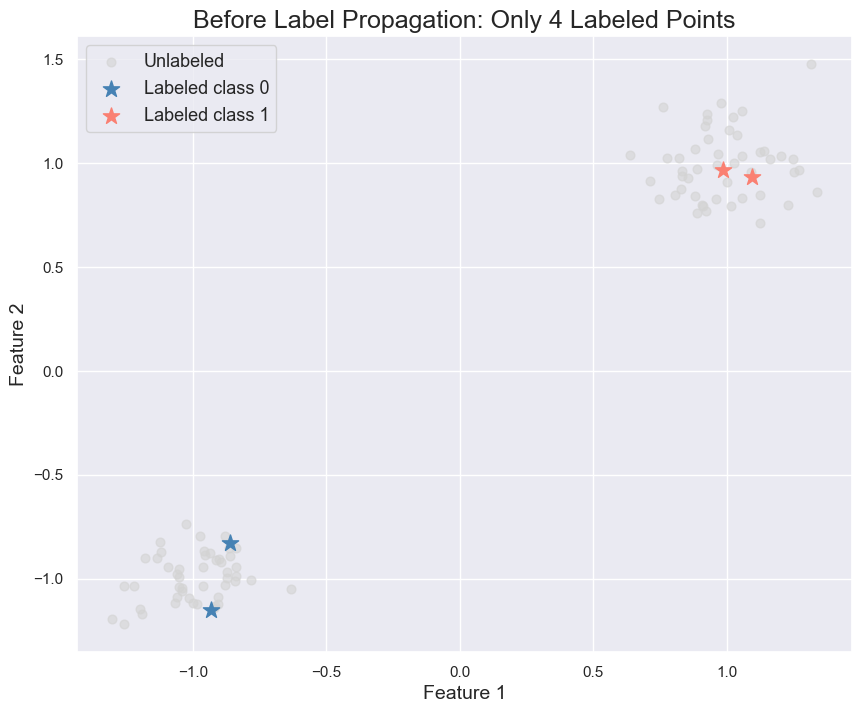

In [23]:
# Visualize before propagation
plt.figure(figsize=(10, 8))
plt.scatter(X_scaled[y == -1, 0], X_scaled[y == -1, 1],
            c='lightgray', label='Unlabeled', alpha=0.6, s=40)
plt.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1],
            c='steelblue', label='Labeled class 0', s=150, marker='*', zorder=5)
plt.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1],
            c='salmon', label='Labeled class 1', s=150, marker='*', zorder=5)
plt.xlabel('Feature 1', fontsize=14)
plt.ylabel('Feature 2', fontsize=14)
plt.title('Before Label Propagation: Only 4 Labeled Points', fontsize=18)
plt.legend(fontsize=13)
plt.show()

## Run Label Propagation

In [24]:
lp = LabelPropagation(gamma=2.0, n_iterations=500)
lp.fit(X_scaled, y)

labels = lp.predict()
print(f'Predicted labels: {dict(zip(*np.unique(labels, return_counts=True)))}')

Predicted labels: {np.int64(0): np.int64(50), np.int64(1): np.int64(50)}


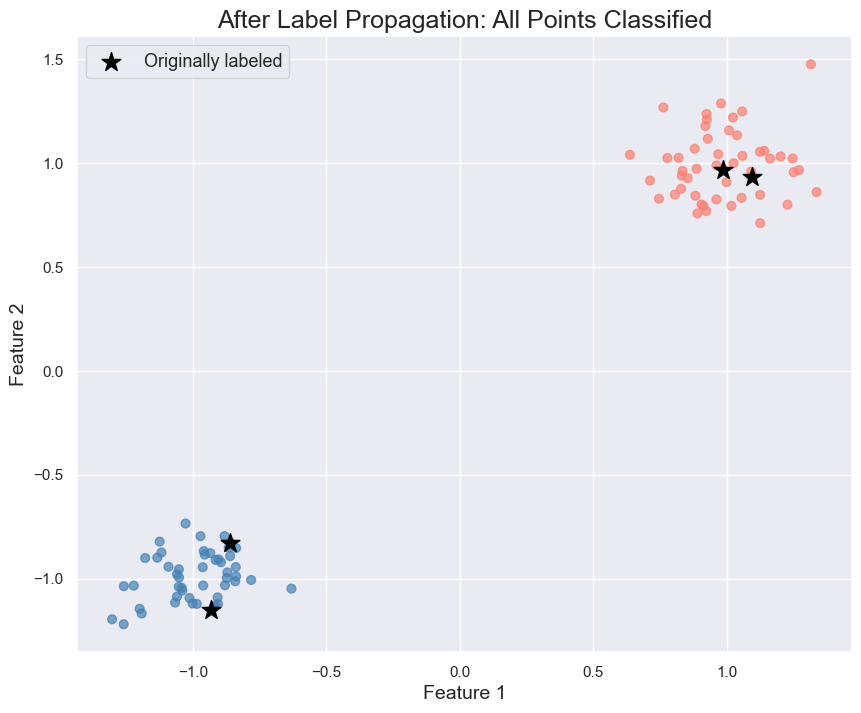

In [25]:
# Visualize after propagation
colors = np.where(labels == 0, 'steelblue', 'salmon')

plt.figure(figsize=(10, 8))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, alpha=0.7, s=40)
plt.scatter(X_scaled[y != -1, 0], X_scaled[y != -1, 1],
            c='black', s=200, marker='*', zorder=5, label='Originally labeled')
plt.xlabel('Feature 1', fontsize=14)
plt.ylabel('Feature 2', fontsize=14)
plt.title('After Label Propagation: All Points Classified', fontsize=18)
plt.legend(fontsize=13)
plt.show()

In [26]:
# Accuracy against true cluster membership
y_true = np.array([0]*50 + [1]*50)
from rice_ml.metrics import accuracy_score

# Account for possible label flip (propagation may assign 0 to cluster 1)
acc = max(
    accuracy_score(y_true, labels),
    accuracy_score(y_true, 1 - labels)
)
print(f'Accuracy vs true clusters: {acc:.4f}')

Accuracy vs true clusters: 1.0000


## Effect of gamma on Propagation

- **Large gamma:** tight RBF kernel. labels propagate only to very close neighbors. risk of incomplete propagation if the graph is disconnected
- **Small gamma:** wide kernel. labels spread further. risk of crossing cluster boundaries

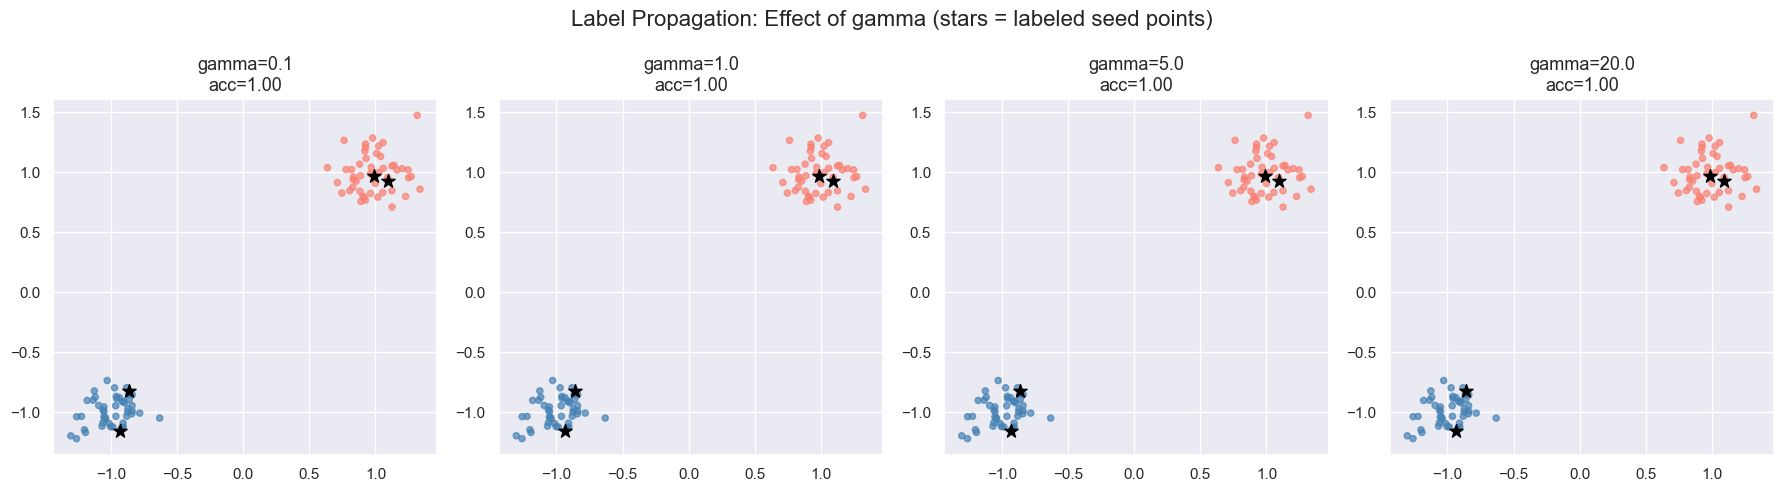

In [27]:
gamma_values = [0.1, 1.0, 5.0, 20.0]
fig, axes = plt.subplots(1, len(gamma_values), figsize=(18, 5))

for ax, gamma in zip(axes, gamma_values):
    lp_g = LabelPropagation(gamma=gamma, n_iterations=300)
    lp_g.fit(X_scaled, y)
    pred = lp_g.predict()
    c = np.where(pred == 0, 'steelblue', 'salmon')
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=c, alpha=0.7, s=20)
    ax.scatter(X_scaled[y != -1, 0], X_scaled[y != -1, 1],
               c='black', s=100, marker='*', zorder=5)
    acc_g = max(accuracy_score(y_true, pred), accuracy_score(y_true, 1-pred))
    ax.set_title(f'gamma={gamma}\nacc={acc_g:.2f}', fontsize=13)

plt.suptitle('Label Propagation: Effect of gamma (stars = labeled seed points)', fontsize=16)
plt.tight_layout()
plt.show()

## Interpretation

- Label propagation leverages the **manifold assumption**: nearby points in feature space likely share the same label.
- Only **4 labeled points out of 100** are enough to classify the full dataset when clusters are well-separated. the unlabeled points form a connected subgraph within each cluster.
- The RBF bandwidth $\gamma$ controls the neighborhood size: tune it so the resulting graph connects points within the same cluster but not across clusters.
- **Clamping** ensures labeled points never change their labels during iteration: they act as anchors that pull nearby unlabeled points toward the correct class.
- The closed-form solution $F^* = (I - T_{uu})^{-1} T_{ul} F_l$ shows that propagation solves a linear system: the inverse exists whenever the graph is connected within each class (which it is when clusters are well-separated).
- For the gamma sweep: very small gamma (0.1) creates a near-complete graph with almost uniform weights, so labels spread everywhere including across cluster boundaries. very large gamma (20) creates a sparse graph where some unlabeled points are never reached by any labeled point.